Question: how does learning rate affect performance?

In [1]:
import os, shutil
from training import TrainingHistory, fit_model
from training import fit_model
# from training_data import TrainingData, Normalizer
import matplotlib.pyplot as plt

2023-10-26 00:35:53.096211: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-26 00:35:54.031410: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
save_path = "models/test_learning_rate"
training_data_path = "training_data"

In [3]:
from training_data import load_training_data
training_data = load_training_data(training_data_path)
levels = list(training_data.levels.keys())
rates = [1e-2, 1e-3, 1e-4]
save_paths = {rate:f"{save_path}/rate_{rate:0.02g}" for rate in rates}

In [4]:
if os.path.exists(save_path):
    shutil.rmtree(save_path)
training_level = 'd0.40'
train_depth = 0.9
for rate in rates:
    print(f"=== training at rate {rate:0.02g} ===")
    fit_model(
        training_data=training_data_path,
        training_level=training_level,
        train_depth=train_depth,
        learning_rate=rate,
        save_path=save_paths[rate],
        model_type='ResNet101V2',
    )

=== training at rate 0.01 ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples


2023-10-26 00:36:00.374751: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22246 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10


2023-10-26 00:36:30.991447: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2023-10-26 00:36:32.331329: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-10-26 00:36:33.422125: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1e0b4fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-10-26 00:36:33.422173: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-10-26 00:36:33.437879: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-10-26 00:36:33.638525: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proce


Batch 0


...

 100/1554 [>.............................] - ETA: 9:06 - loss: 0.0787
Batch 100
    Training MSE (xyz, xy, z): 0.07085346811211231 0.07504075683229444 0.06247889067174806  Slopes: [-0.017836298654752954, -0.018330080570367613, -0.012531582880462213]
    Validation d0.00  MSE (xyz, xy, z): 0.0204 0.0216 0.018  Slopes: -0.0185 -0.0189 -0.0124
    Validation d0.20  MSE (xyz, xy, z): 0.0411 0.0504 0.0224  Slopes: -0.0179 -0.018 -0.0168
    Validation d0.40  MSE (xyz, xy, z): 0.0807 0.096 0.0501  Slopes: -0.0173 -0.0175 -0.0158
    Validation d0.60  MSE (xyz, xy, z): 0.211 0.258 0.118  Slopes: -0.016 -0.0161 -0.015
    Validation d0.80  MSE (xyz, xy, z): 0.659 0.807 0.362  Slopes: -0.0108 -0.0107 -0.0113
    Validation d1.00  MSE (xyz, xy, z): 0.976 1.13 0.662  Slopes: -0.00718 -0.00758 -0.0056
 200/1554 [==>...........................] - ETA: 12:48 - loss: 0.0611
Batch 200
    Training MSE (xyz, xy, z): 0.05712009767035527 0.06430809943140713 0.042744094148251574  Slopes: [-0.0129689450931

INFO:tensorflow:Assets written to: models/test_learning_rate/rate_0.001/fit_model/assets


=== training at rate 0.0001 ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10

Batch 0
saving weigt

 100/1554 [>.............................] - ETA: 9:07 - loss: 0.1683
Batch 100
    Training MSE (xyz, xy, z): 0.1716949246825724 0.194933926267224 0.12521692151326919  Slopes: [-0.012301108262007004, -0.01264406131424863, -0.01099374874040044]
    Validation d0.00  MSE (xyz, xy, z): 0.122 0.133 0.101  Slopes: -0.0142 -0.0151 -0.00749
    Validation d0.20  MSE (xyz, xy, z): 0.13 0.133 0.126  Slopes: -0.0132 -0.0142 -0.00954
    Validation d0.40  MSE (xyz, xy, z): 0.185 0.207 0.142  Slopes: -0.0117 -0.012 -0.0105
    Validation d0.60  MSE (xyz, xy, z): 0.318 0.382 0.191  Slopes: -0.0089 -0.00904 -0.00828
    Validation d0.80  MSE (xyz, xy, z): 0.689 0.67 0.726  Slopes: -0.00314 -0.00409 -0.00104
    Validation d1.00  MSE (xyz, xy, z): 1.01 0.956 1.1  Slopes: -0.00131 -0.00331 0.00357
 200/1554 [==>...........................] - ETA: 12:50 - loss: 0.1275
Batch 200
    Training MSE (xyz, xy, z): 0.10107079907247325 0.12535353099661864 0.05250533522418249  Slopes: [-0.009353609955108448, -

INFO:tensorflow:Assets written to: models/test_learning_rate/rate_0.0001/fit_model/assets


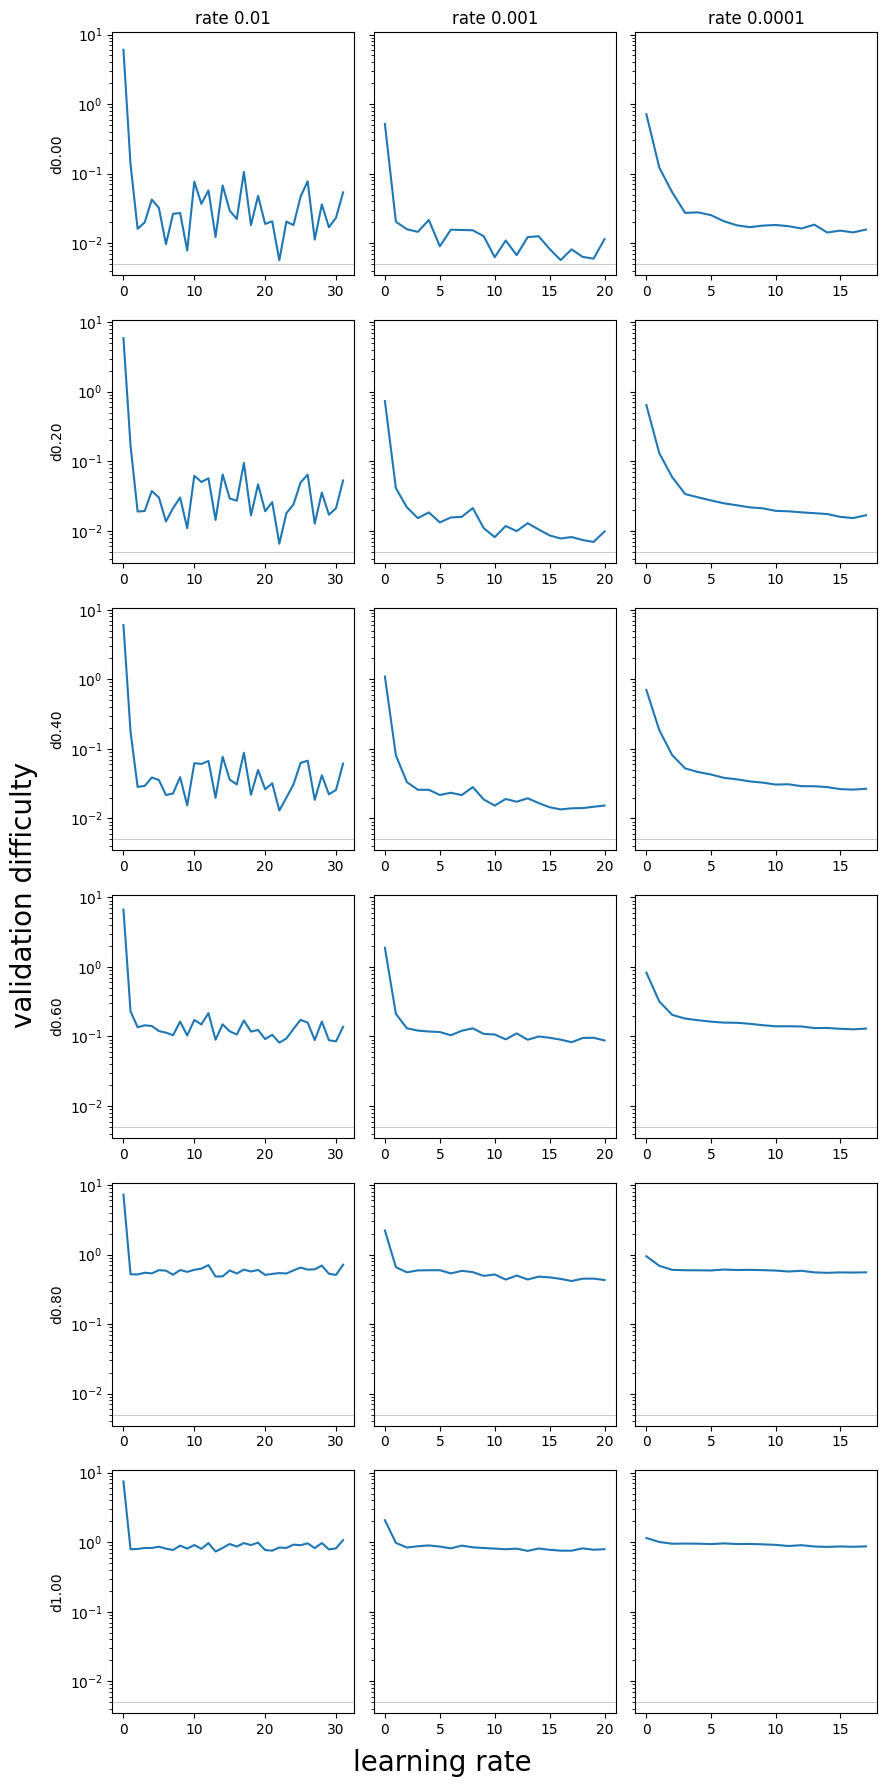

In [5]:
fig, ax = plt.subplots(len(levels), len(rates), figsize=(len(rates)*3, len(levels)*3), sharey=True)
fig.supylabel('validation difficulty', fontsize=20)
fig.supxlabel('learning rate', fontsize=20)
for i, level in enumerate(levels):
    ax[i, 0].set_ylabel(level)
for i,rate in enumerate(rates):
    history = TrainingHistory(f'{save_paths[rate]}/training_history.json')
    history.plot_loss(metrics=['mse'], ax=ax[:, i:i+1])
    ax[0, i].set_title(f"rate {rate}")
fig.tight_layout()

In [6]:
from model import PipetteDetectionModel
depth = 1.0
model = PipetteDetectionModel(load_model=save_paths[depth])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None


1/1 [==============================] - 0s 65ms/step


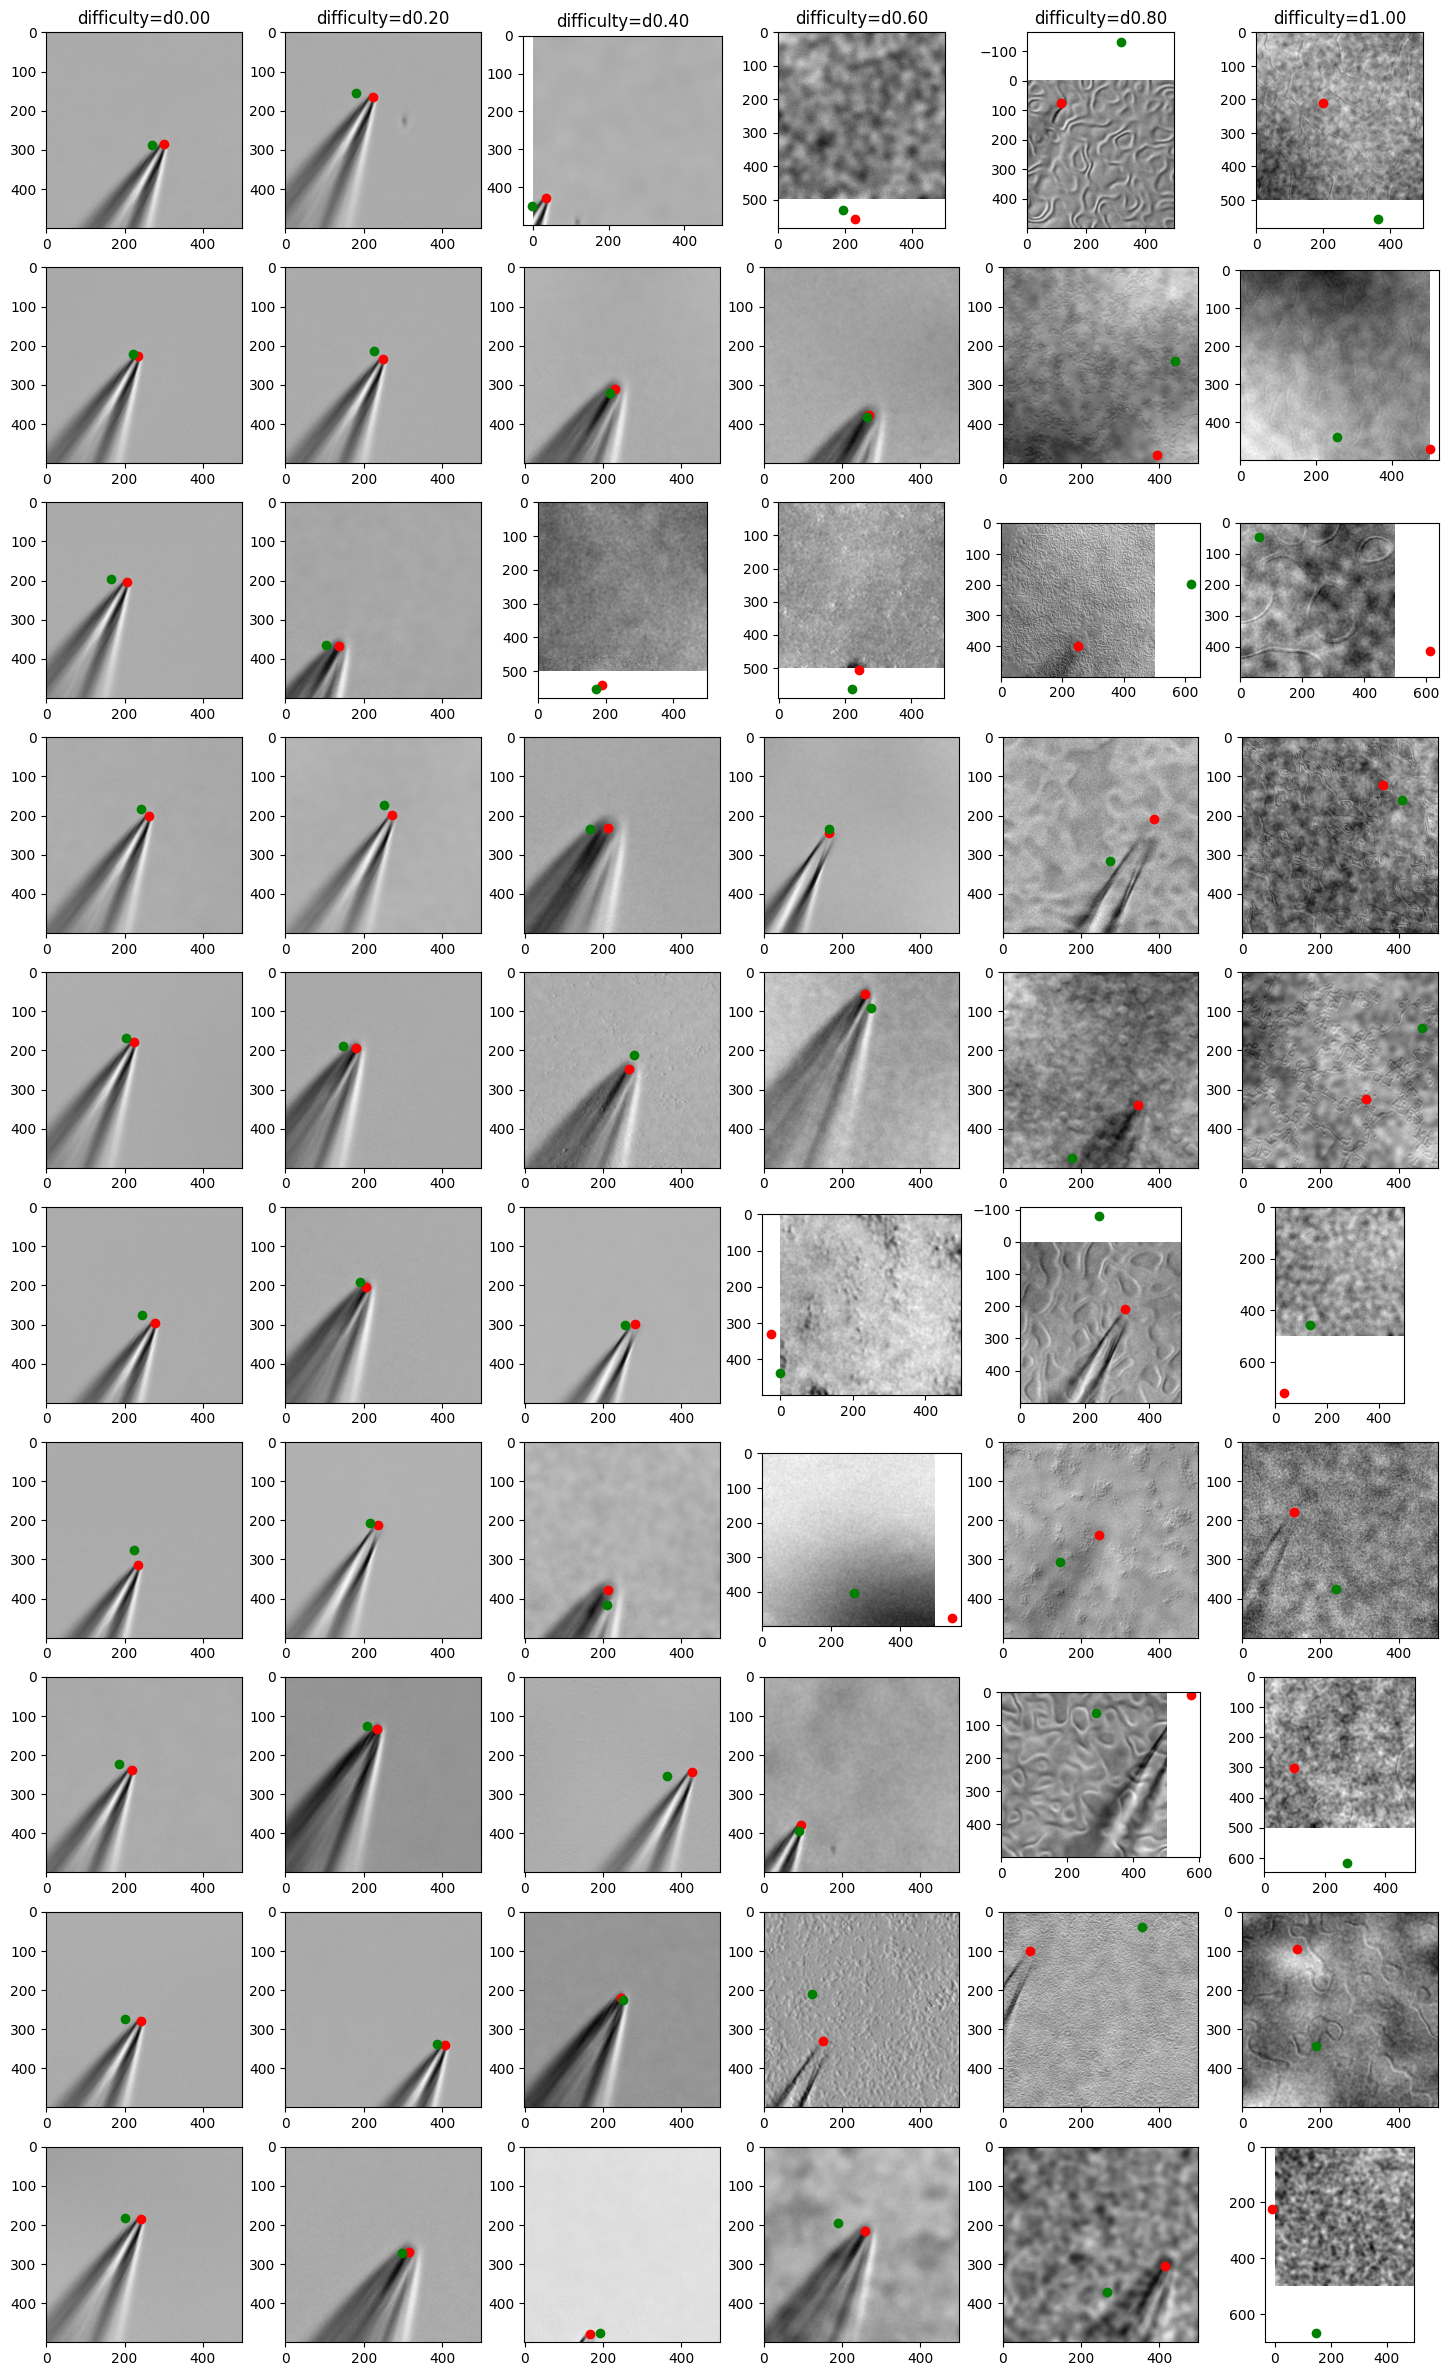

In [7]:
shape = (10, len(levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j, level in enumerate(levels):
    ax[0,j].set_title(f"difficulty={level}")
    image, pip_pos = training_data.levels[level][:shape[0]].get_arrays()
    pip_pos = training_data.output_norm.denormalize(pip_pos)
    pred = training_data.output_norm.denormalize(model.model.predict(image))
    for i in range(shape[0]):
        ax[i,j].imshow(image[i], cmap='gray')
        ax[i,j].scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
        ax[i,j].scatter(pred[i, 2], pred[i, 1], color='green')
        